<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Flexão de vigas constituídas por vários materiais

### Problema 6

A viga de betão armado representada na figura tem uma secção transversal retangular com 600 mm de altura e 300 mm de largura, é reforçada com quatro varões de aço com diâmetro $d =$ 22 mm e suporta um momento fletor positivo $M = 160$ kN.m. Sabendo que o módulo de elasticidade do betão é $E_b =$ 25 GPa e o do aço é $E_a$ = 200 GPa, determine as tensões máximas que ocorrem no betão e no aço.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au02/P6/MSII_Au02_P6.png"
style="max-height: 100%; max-width: 100%;"/>

### Resolução

##### Dados do problema

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa
# Create an empty class
class varin: pass

Bet = varin()
Aco = varin()
S = varin()

Mf = 160.1e6 # unit: N.mm

Aco.E = 200.e3 # MPa
Aco.d = 22      # unit: mm
Bet.E = 25.e3 # MPa

S.l1 = 300. # mm
S.l2 = 50. # mm
S.h1 = 50. # mm
S.h2 = 500. # mm
S.ht = S.h1 + S.h2

### Secção homogénea (hipótese)

Uma vez que o betão da viga apenas suporta compressão, considera-se apenas a região localizada acima da linha do eixo neutro (na zona de compressão) na secção transformada, ignorando assim o betão na zona de tração da viga. Segundo este modelo, assume-se também que o estado de tensão no betão varia linearmente a partir da posição do eixo neutro.

Por outro lado, a área transformada do aço ($nA_a$) encontra-se a uma determinada distância entre a linha do eixo neutro e o centroide da sua secção. Pressupõe-se que a tensão de tração no aço é uniforme.

Para obter a secção transformada da viga em betão armado, é possível substituir a área total da secção transversal $A_a$ das barras de aço por uma área equivalente ($nA_a$), onde $n$ é a relação entre os módulos de elasticidade do aço e do betão $E_a/E_b$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au02/P6/MSII_Au02_P6a.png"
width="1200" />


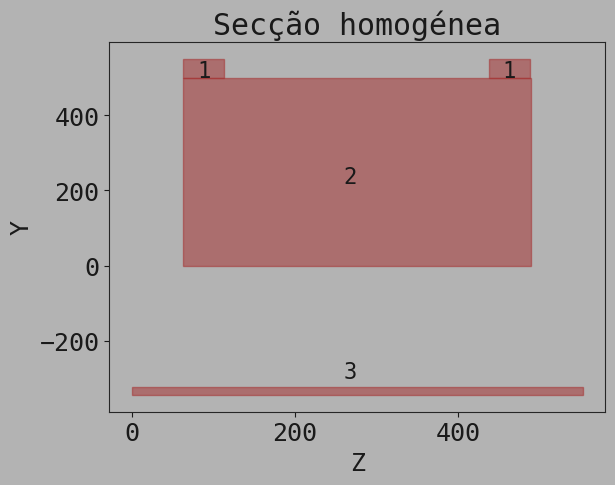

In [2]:
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((0, -344), 553, Aco.d,color="brown",alpha=0.5))
ax.add_patch(Rectangle(((553-S.l1)/4, 0), S.l1+(553-S.l1)/2, S.h2,color="brown",alpha=0.5))
ax.add_patch(Rectangle(((553-S.l1)/4, S.h2), S.l2, S.h1,color="brown",alpha=0.5))
ax.add_patch(Rectangle(((553-(553-S.l1)/2.2), S.h2), S.l2, S.h1,color="brown",alpha=0.5))
l1 = np.array((80, 500)); ax.text(*l1,'1', fontsize=16, rotation_mode='anchor')
l2 = np.array((455, 500)); ax.text(*l2,'1', fontsize=16, rotation_mode='anchor')
l3 = np.array((260, 220)); ax.text(*l3,'2', fontsize=16, rotation_mode='anchor')
l4 = np.array((260, -300)); ax.text(*l4,'3', fontsize=16, rotation_mode='anchor')
plt.xlabel("Z")
plt.ylabel("Y")
plt.title("Secção homogénea")
plt.show()

#### Área de transformação
  
- Área total do aço:

\begin{equation*}
A_a = 4\left( \frac{\pi d²}{4} \right)
\quad\wedge\quad
n = \frac{E_a}{E_b}
\quad\therefore\quad
A_{a2b} = n A_a = \left( \frac{E_a}{E_b} \right) \pi d²
\end{equation*}

em que, $A_a$ é a área do aço, $n$ é o rácio de módulos, $A_{a2b} $ é a área equivalente de betão na região do aço.

In [3]:
Aco.A = 4*(np.pi*Aco.d**2)/4
print(f'Are cross-section of steel = {Aco.A:.1f} mm²')
S.n = Aco.E/Bet.E
print(f'S.n = Eb/Ea = {S.n:.1f} ')
S.Aa2b = S.n*Aco.A
print(f'S.Aa2b  = n.Aa = {S.Aa2b:.1f} mm²')

Are cross-section of steel = 1520.5 mm²
S.n = Eb/Ea = 8.0 
S.Aa2b  = n.Aa = 12164.2 mm²


- cálculo da largura da área equivalente, mantendo uma altura igual ao diâmetro das barras de aço
  
\begin{equation*}
A_{a2b} = l_{a2b} \cdot d_a
\quad\therefore\quad
l_{a2b} = \frac{A_{a2b}}{d_a}
\quad\textrm{[m]}
\end{equation*}

In [4]:
S.la2b = S.Aa2b/Aco.d
print(f'la2b = {S.la2b:.1f} mm')

la2b = 552.9 mm


#### Posição do eixo neutro da secção tranformada

- Neste exemplo, como se pode determinar a posição do eixo neutro da secção transformada (varíavel $k \equiv x$ na figura acima)?

A posição do eixo neutro é obtida ao determinar a distância $k\equiv x$ a partir da face superior da viga até ao centróide $C$ da secção transformada (ver figura acima). A condição para a determinação da posição do eixo neutro é que o primeiro momento de área da secção transformada seja nulo em relação ao eixo neutro: $\int_{A} y \mathrm{d}A = 0$. Visto que o primeiro momento de cada parte da secção transformada é obtido multiplicando a sua área pela distância do seu próprio centróide em relação ao eixo neutro, resulta:

\begin{equation*}
\int_{A} y \mathrm{d}A = 0\quad\therefore\quad
\int_{A_\mathrm{b}} y \mathrm{d}A + \int_{A_\mathrm{a}} y \mathrm{d}A = 0
\quad\Leftrightarrow\quad
\overline{y_b}A_b + \overline{y_a}A_a = 0
\end{equation*}

Desenvolvendo,

\begin{equation*}
\begin{aligned}
&(\overline{y})[A]\Big|_{a2b} = (\overline{y})[A]\Big|_b \quad\Leftrightarrow\quad~ (\overline{y})[A]\Big|_{a2b} = (\overline{y})[A]\Big|_{b,1}^\Box + (\overline{y})[A]\Big|_{b,2}^{\Box} \\
\Leftrightarrow & (550 - k)[A_{a2b}] = (k-25)[2(50\cdot50)] + \left(\frac{k-50}{2}\right)[300(k-50)]
\end{aligned}
\end{equation*}

In [8]:
k = sy.symbols('k')
EQ = (S.h1+S.h2-k)*S.Aa2b - 2*(S.h1**2)*(k-S.h1/2) - S.l1*(k-S.h1)**2/2
simplified_EQ = sy.simplify(EQ)
print(f'Eq(k) = {sy.simplify(EQ)}')
sol = sy.solve(EQ,k)
print(sol)
K = sol[1]
print(f'K = {K:.1f} mm')

Eq(k) = -150.0*k**2 - 2164.24675469968*k + 6440335.71508482
[-214.548705498864, 200.120393800866]
K = 200.1 mm


#### Momento de inércia de área da secção tranformada

É necessário calcular o momento de inércia de área da secção transformada pela adição do momento de inércia de área de 3 regiões elementares: 

\begin{equation*}
\begin{aligned}
I_t = \underbrace{\overline{I}_1 + A_1 d_1²}_{\textrm{a2b}}
+ \underbrace{\overline{I}_2 + A_2 d_3²}_{\textrm{b1}}
+ \underbrace{\overline{I}_3 + A_3 d_3²}_{\textrm{b2}}
\end{aligned}
\end{equation*}

In [9]:
def iret(b,h): return b*h**3/12

print('::::::::::::::::::::::::::::::')
A1 = S.Aa2b
print(f'A1 = {A1:.1f} mm²')
d1 = S.h1+S.h2-K
print(f'd1 = {d1:.1f} mm')
Ic1 = iret(S.la2b,Aco.d)
print(f'Ic1 = {Ic1:.1f} mm^4')
I1 = Ic1 + A1*d1**2
print(f'I1 = {I1:.1f} mm^4')

print('::::::::::::::::::::::::::::::')
A2 = S.l1*(K-S.h1)
print(f'A2 = {A2:.1f} mm²')
d2 = (K-S.h1)/2
print(f'd2 = {d2:.1f} mm')
Ic2 = iret(S.l1,K-S.h1)
print(f'Ic2 = {Ic2:.1f} mm^4')
I2 = Ic2 + A2*d2**2
print(f'I2 = {I2:.1f} mm^4')

print('::::::::::::::::::::::::::::::')
A3 = S.l2*S.h1
print(f'A3 = {A3:.1f} mm²')
d3 = K-S.h1/2
print(f'd3 = {d3:.1f} mm')
Ic3 = 2*iret(S.l2,S.h1)
print(f'Ic3 = {Ic3:.1f} mm^4')
I3 = 2*(Ic3 + A3*d3**2)
print(f'I3 = {I3:.1f} mm^4')

print('\n::::::::::::::::::::::::::::::')
Iz = I1 + I2 + I3
print(f'Iz = {Iz:.1f} mm^4')

::::::::::::::::::::::::::::::
A1 = 12164.2 mm²
d1 = 349.9 mm
Ic1 = 490624.6 mm^4
I1 = 1489585878.5 mm^4
::::::::::::::::::::::::::::::
A2 = 45036.1 mm²
d2 = 75.1 mm
Ic2 = 84578327.6 mm^4
I2 = 338313310.6 mm^4
::::::::::::::::::::::::::::::
A3 = 2500.0 mm²
d3 = 175.1 mm
Ic3 = 1041666.7 mm^4
I3 = 155419095.0 mm^4

::::::::::::::::::::::::::::::
Iz = 1983318284.0 mm^4


##### Determine as tensões máximas que ocorrem no betão e no aço

- Betão:

\begin{equation*}
\sigma_\textrm{b} = -\frac{M_f}{I_t}y
\end{equation*}

- Aço:

\begin{equation*}
\sigma_\textrm{a} = -n\left(\frac{M_f}{I_t}y\right)
\end{equation*}

In [7]:
yb = K
Sb = -Mf/Iz*yb
print(f'Sb = {Sb:.1f} MPa')

ya = - (S.ht - K)
Sa = -Mf/Iz*ya*S.n
print(f'Sa = {Sa:.1f} MPa')

Sb = -16.2 MPa
Sa = 225.9 MPa


#### Bibliografia

[1] Ferdinand Beer et al - Mechanics of Materials 8Ed (2020) Chapter 4 Pure Bending, p. 262

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>